In [3]:
import torch
from SE2EikonalSolverPyTorch import eikonal_solver, geodesic_back_tracking
import matplotlib.pyplot as plt
import h5py
from math import ceil
from tqdm.auto import tqdm

device = "cuda"

test = False
nmr = 0
index = 6

## Import initial guess boundary structure

In [4]:
No = 12 
shape = (No,1001,1001)

if test == False:
    connected_components = torch.load(f"C:/Users/levis/OneDrive - ASML/Documents/Paper 2- Training Cost Function/learning parameters/Files synthetic/lifted_contours.pt")  
    connected_components_blobs = torch.load(f"C:/Users/levis/OneDrive - ASML/Documents/Paper 2- Training Cost Function/learning parameters/Files synthetic/lifted_contours_blobs.pt") 
else:
    connected_components = torch.load(f"C:/Users/levis/OneDrive - ASML/Documents/Paper 2- Training Cost Function/learning parameters/lifted_contours_test_{index}.pt") 
    connected_components_blobs = torch.load(f"C:/Users/levis/OneDrive - ASML/Documents/Paper 2- Training Cost Function/learning parameters/lifted_contours_blobs_test_{index}.pt") 

connected_components_combined = [
    lines + blobs 
    for lines, blobs in zip(connected_components, connected_components_blobs)
]

connected_components = [[per_comp * torch.tensor([No / (2 * torch.pi),1,1]) for per_comp in per_image] for per_image in connected_components_combined]

cost = torch.ones(*shape) 

source_points = [[tuple([tuple(point.int()) for point in per_comp]) for per_comp in per_image] for per_image in connected_components]

# Tessellation of position-orientation space 

Compute a tessellation of position-orientation space by assigning each voxel to the nearest connected component, that contains the structure boundary.

In [5]:
dxy = 1. #2. * torch.pi / (shape[1] - 1)

mask_cost_functions = []

for image in source_points:
    result_per_image = []
    for comp in tqdm(image):
        
        r = 20
        y_min = max(min([p[1] for p in comp]) - r, 0)
        y_max = min(max([p[1] for p in comp]) + r, shape[1]) 

        x_min = max(min([p[2] for p in comp]) - r, 0)
        x_max = min(max([p[2] for p in comp]) + r, shape[2]) 
        

        sources_cropped = tuple((theta, y - y_min, x - x_min) 
            for theta, y, x in comp)
        cost_cropped = cost[:,y_min:y_max+1,x_min:x_max+1]
                      
        results_per_comp , _ = eikonal_solver(
                cost_cropped,
                sources_cropped,
                dxy,
                ξ = 1.25,  #1.25 (every line of 5 pixels has the same length as an inplace rotation of 2pi, 5 pixels times \xi is approx 2 * 3.14)
                initial_condition=1e3,
                n_max=5000,
                controller="sub-Riemannian",
                device=device,
                verbose=False
            )
        
        cost_grouped = torch.ones(cost.shape)*1e8
        cost_grouped[:,y_min:y_max+1,x_min:x_max+1] = results_per_comp
        
        # fig, ax = plt.subplots(1, 1, figsize=(6, 6))
        # cbar = ax.contour(cost_grouped.min(0)[0], levels=(1, 2, 3, 4, 5))
        # fig.colorbar(cbar, ax=ax)
        # plt.show()

        result_per_image.append(cost_grouped)
            
    # stack per image
    W_sR = torch.stack(result_per_image)
    print(W_sR.shape)
    
    # Compute the minimum over the first dimension
    min_vals, min_args = torch.min(W_sR, dim=0, keepdim=False)

    mask_cost_functions.append(min_args)



  0%|          | 0/392 [00:00<?, ?it/s]

torch.Size([392, 12, 1001, 1001])


  0%|          | 0/395 [00:00<?, ?it/s]

torch.Size([395, 12, 1001, 1001])


KeyboardInterrupt: 

In [7]:
if test == False :
    #torch.save(mask_cost_functions, f"mask_cost_functions_shift_{nmr}.pt") 

    mask_cost_functions = torch.load(f"C:/Users/levis/OneDrive - ASML/Documents/Paper 2- Training Cost Function/learning parameters/Files synthetic/mask_cost_functions.pt") 
    
    costfunctions = torch.load(f"C:/Users/levis/OneDrive - ASML/Documents/Paper 2- Training Cost Function/learning parameters/Files synthetic/costfunctions_nobin.pt") 
else:
    #torch.save(mask_cost_functions, f"mask_cost_functions_test_{index}.pt")

    mask_cost_functions = torch.load(f"C:/Users/levis/OneDrive - ASML/Documents/Paper 2- Training Cost Function/learning parameters/mask_cost_functions_test_{index}.pt") 
    costfunctions = torch.load(f"C:/Users/levis/OneDrive - ASML/Documents/Paper 2- Training Cost Function/learning parameters/Files synthetic/costfunctions_test_{index}.pt") 

In [8]:
grouped_costfunctions = []
for i,c in enumerate(costfunctions[:1]):

    if mask_cost_functions[i].shape == c.shape:
        grouped_costfunctions.append(torch.where(
                mask_cost_functions[i] == 80,
                c,
                torch.ones_like(mask_cost_functions[i])
            ))
    else:
        print("bad! Shape of mask is not the same as shape of the cost function")



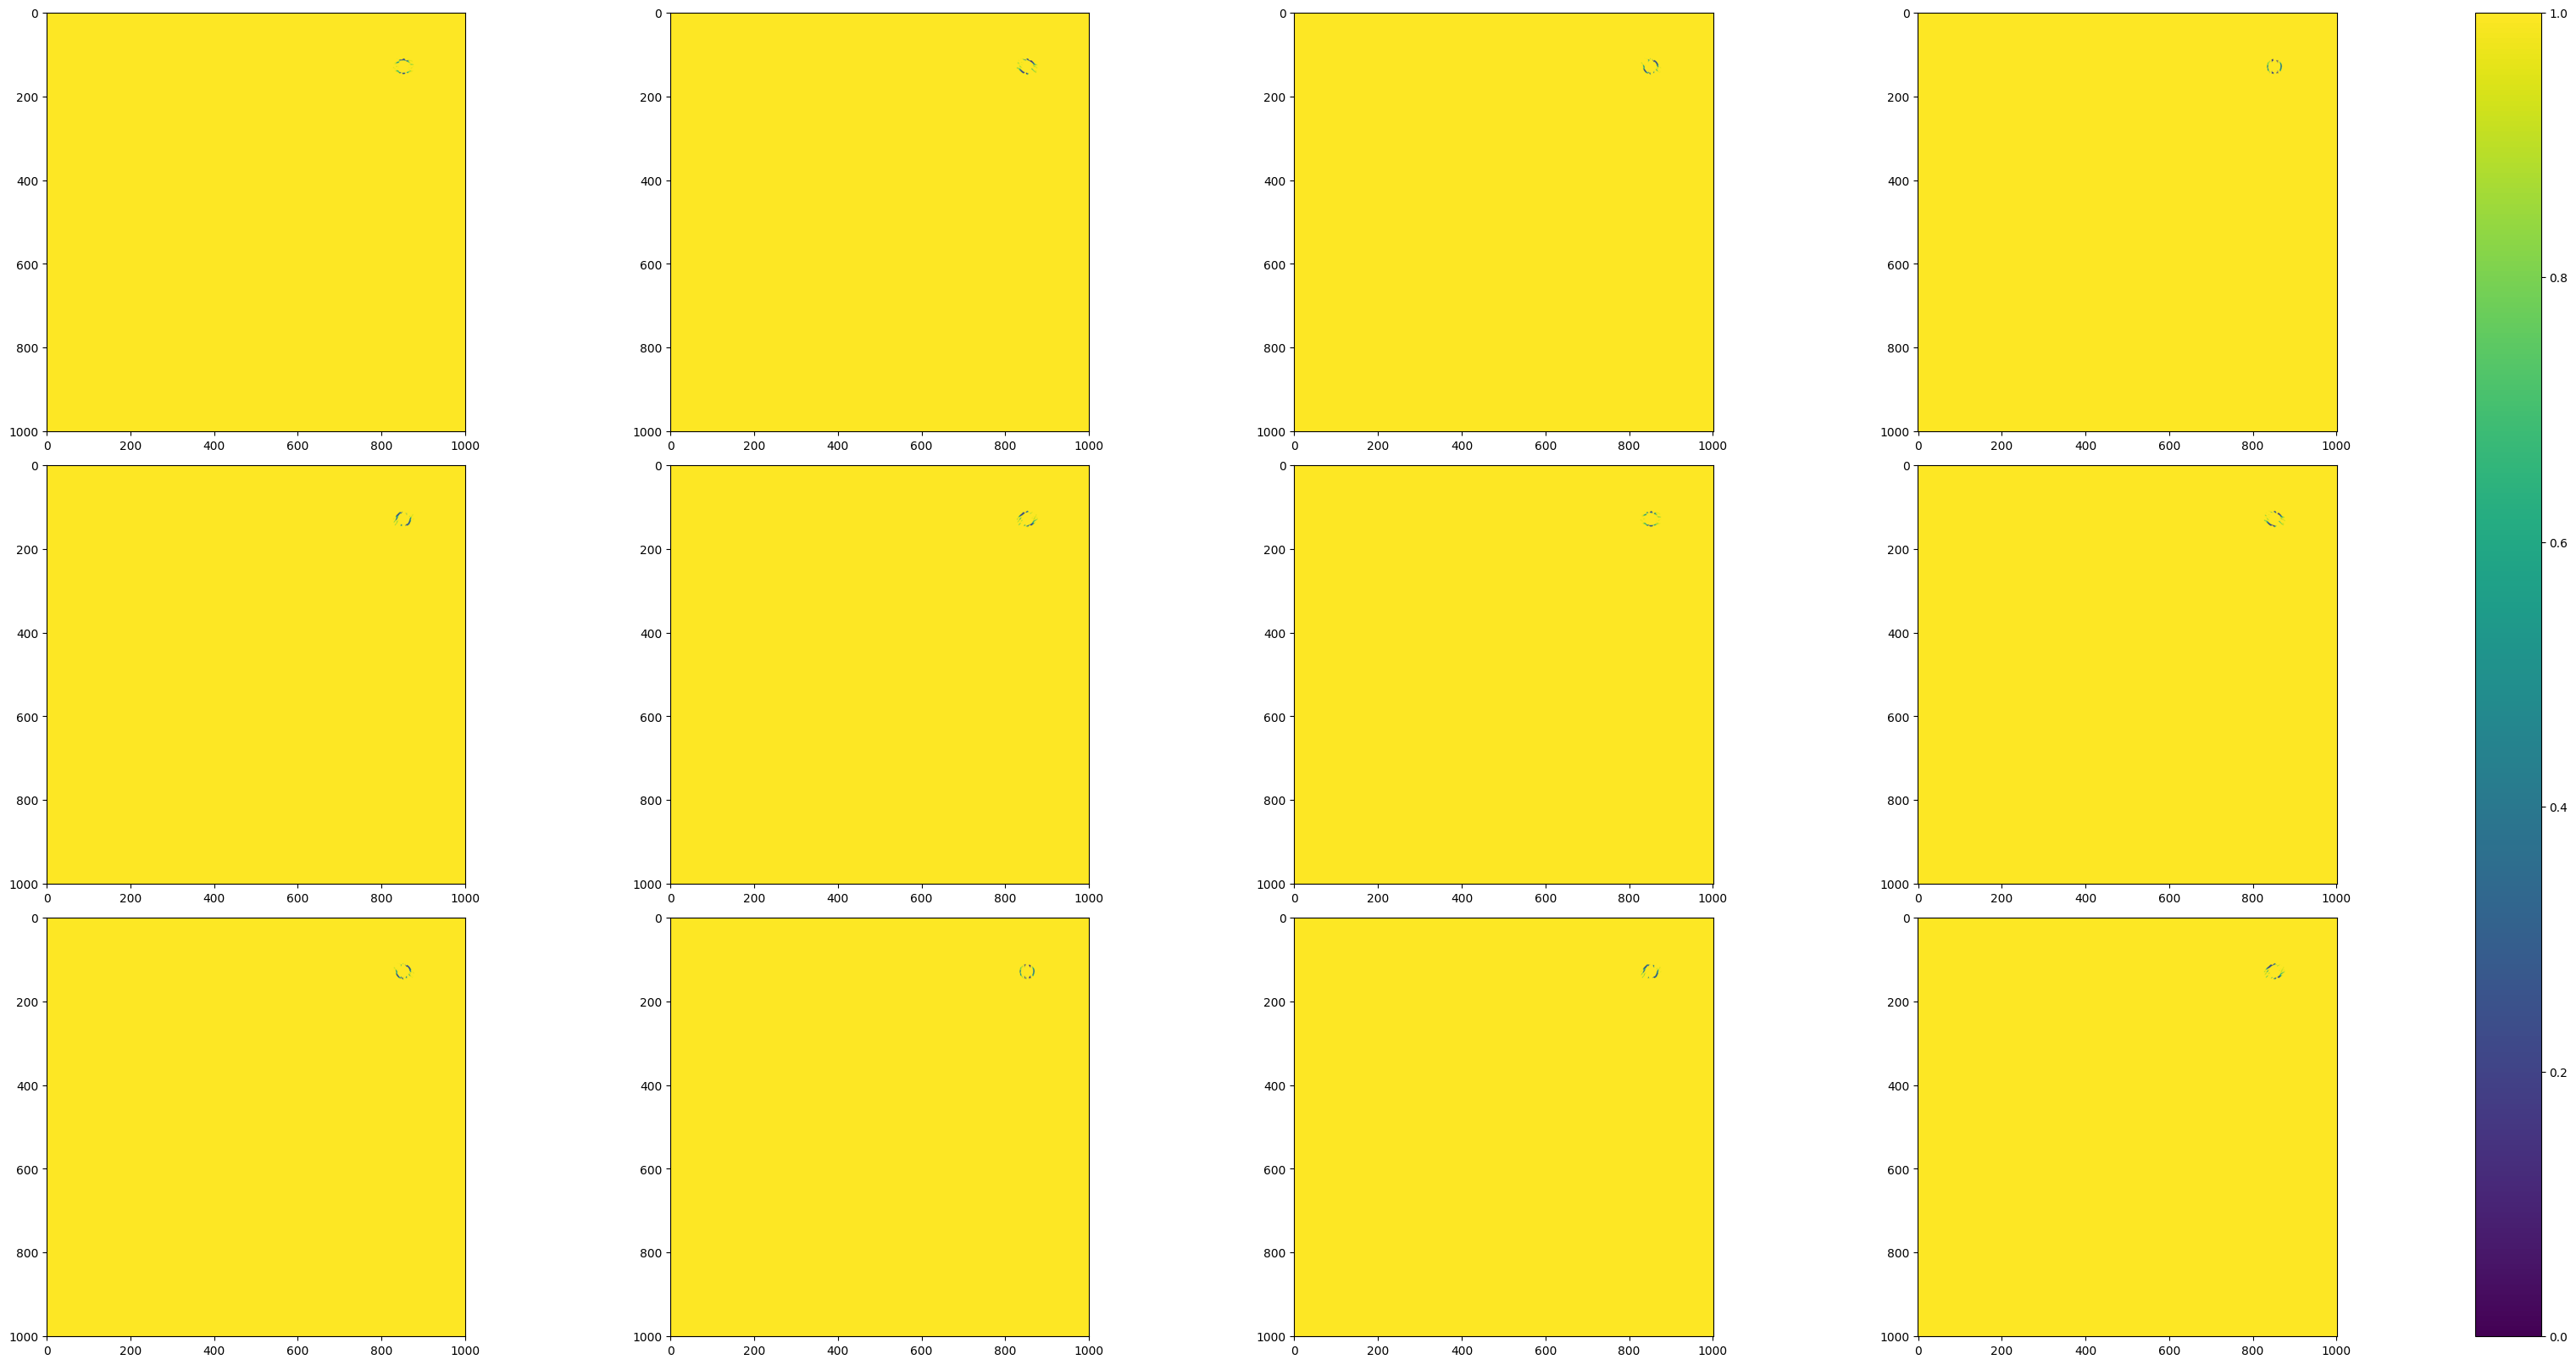

In [9]:
vmin = 0
vmax = 1

fig, ax = plt.subplots(ceil(grouped_costfunctions[0].shape[0]/4), 4, figsize=(8 * 4, 4 * 4), layout="constrained")

ims = []
for i in range(ceil(grouped_costfunctions[0].shape[0]/4)):
    for j in range(4):
        im = ax[i, j].imshow(grouped_costfunctions[0][i * 4 + j, :, :].cpu(), vmin=vmin, vmax=vmax,
                        cmap="viridis",
                        aspect="equal")
        ims.append(im)

fig.colorbar(ims[0], ax=ax, location="right");

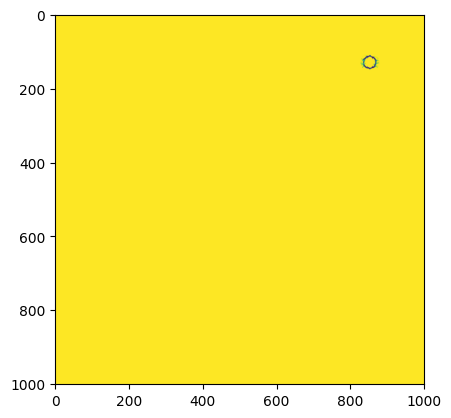

In [10]:
plt.imshow(grouped_costfunctions[0].min(0)[0].cpu())